## Plots $N=4$

In [2]:
import qutip as qt
import numpy as np
import matplotlib.pyplot as plt
from iminuit import Minuit
from iminuit.cost import LeastSquares  
from core_functions_Trotter import *

In [3]:
I = qt.qeye(2)

def pauli_tensors(pauli, N):
        return [qt.tensor(*(pauli if k==i else I for k in range(N))) for i in range(N)]

def generate_heisenberg_hamiltonians(N, couplings, b, theta_mix):
    sx = pauli_tensors(qt.sigmax(), N)
    sy = pauli_tensors(qt.sigmay(), N)
    sz = pauli_tensors(qt.sigmaz(), N)

    H_0 = 0
    H_int = 0
    H_XY = 0
    H_XZ = 0
    H_YZ = 0

    for i in range(N):
        H_0 += b*(np.sin(2*theta_mix)*sx[i] - np.cos(2*theta_mix)*sz[i])
        for j in range(i+1, N):
            g = couplings[f"g{i+1}_{j+1}"]

            H_int += g*(sx[i]*sx[j] + sy[i]*sy[j] + sz[i]*sz[j])
            H_XY  += 0.5*g*(sx[i]*sx[j] + sy[i]*sy[j])
            H_XZ  += 0.5*g*(sx[i]*sx[j] + sz[i]*sz[j])
            H_YZ  += 0.5*g*(sy[i]*sy[j] + sz[i]*sz[j])

    return H_0, H_int, H_XY, H_XZ, H_YZ

In [4]:
N = 4   
mu = 1
theta_mixing = 0.195
upsilon = 0.9
b = mu / N # free Hamiltonian 

couplings, _ = fp_couplings(N, upsilon, mu)

def pauli_tensors(pauli, N):
    return [qt.tensor(*(pauli if i==j else I for j in range(N))) for i in range(N)]

sx, sy, sz = pauli_tensors(qt.sigmax(), N), pauli_tensors(qt.sigmay(), N), pauli_tensors(qt.sigmaz(), N)

H_0, H_int, H_XY, H_XZ, H_YZ = generate_heisenberg_hamiltonians(N, couplings, b, theta_mixing)

psi0011 = qt.tensor(qt.basis(2,0), qt.basis(2,0), qt.basis(2,1), qt.basis(2,1)) # |0011>

In [5]:
dt_list = np.arange(1, 41) / mu

def compute_single_step_error_Heisenberg_T1(times):
    U_heis = [(-1j*H_int*t).expm()*(-1j*H_0*t).expm() for t in times]
    U_T1 = [(-1j*(H_YZ)*t).expm()*(-1j*(H_XZ)*t).expm()*(-1j*(H_XY)*t).expm()*(-1j*H_0*t).expm() for t in times]
    add_err_values = [np.max(np.linalg.svd((U_heis[i] - U_T1[i]).full(), compute_uv=False)) for i in range(len(times))]
    return U_heis, U_T1, add_err_values

_, _, add_T1_vals = compute_single_step_error_Heisenberg_T1(dt_list)

def compute_additive_error_Heisenberg_T2(times):
    U_heis = [(-1j*H_int*t).expm()*(-1j*H_0*t).expm() for t in times]
    U_T2 = [(-1j*(H_XY)*(t/2)).expm()*(-1j*(H_XZ)*(t/2)).expm()*(-1j*(H_YZ)*t).expm()*(-1j*(H_XZ)*(t/2)).expm()*(-1j*(H_XY)*(t/2)).expm()*(-1j*H_0*t).expm() for t in times]
    add_err_values = [np.max(np.linalg.svd((U_heis[i] - U_T2[i]).full(), compute_uv=False)) for i in range(len(times))]
    return U_heis, U_T2, add_err_values

_, _, add_T2_vals = compute_additive_error_Heisenberg_T2(dt_list)

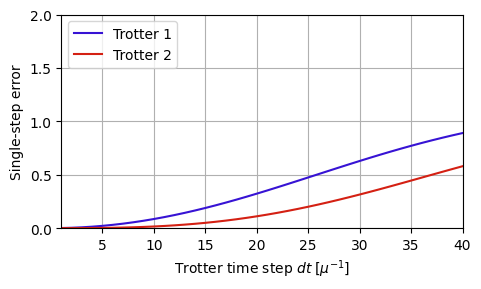

In [6]:
fig, ax=plt.subplots(figsize=(5,3))

ax.plot(dt_list, add_T1_vals, color="#3713d4", label="Trotter 1")
ax.plot(dt_list, add_T2_vals, color="#d42013", label="Trotter 2")
#ax.set_title(r"Spectral norm error between exact and T1 and T2 propagators ($N=4$).")
ax.set_xlabel(r"Trotter time step $dt\;\left[\mu^{-1}\right]$")
ax.set_ylabel(r"Single-step error")
ax.text(0.02, 0.84, rf"", transform=ax.transAxes, fontsize=10, va="center", bbox=dict(boxstyle="round,pad=0.3", fc="white", ec="black"))
ax.legend(loc=2)
ax.set_xlim(np.min(dt_list), np.max(dt_list))
ax.set_ylim(0, 2)

plt.grid()
plt.tight_layout()
fig.savefig(r"C:\Users\edori\Desktop\Nexus\Università\Current\MasterThesis\Images\N4plots\propagator_error_compare_N4.pdf", dpi=300)
plt.show()

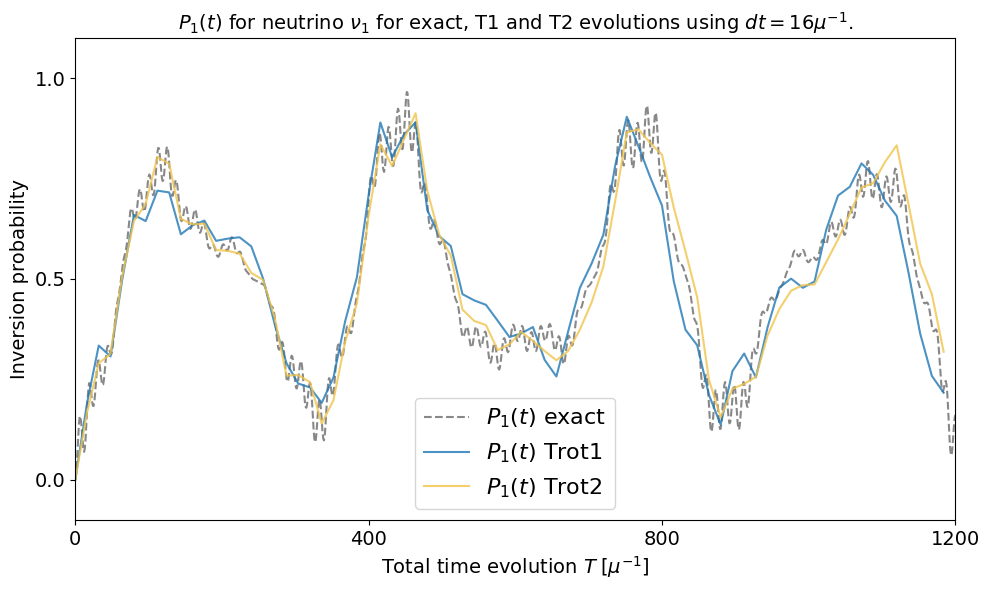

In [15]:
N = 4
mu = 1
theta_mixing = 0.195
upsilon = 0.9
b = mu / N # free Hamiltonian 

couplings, _ = fp_couplings(N, upsilon, mu)

def pauli_tensors(pauli, N):
    return [qt.tensor(*(pauli if i==j else I for j in range(N))) for i in range(N)]

sx, sy, sz = pauli_tensors(qt.sigmax(), N), pauli_tensors(qt.sigmay(), N), pauli_tensors(qt.sigmaz(), N)

T_total = 1201

# dt_fine = 1 / mu
# tlist_fine = [dt_fine*i for i in range(int(T_total/dt_fine))]

# res = qt.mesolve(H_0+H_int, psi0011, tlist_fine, [], [sz[0], sz[1], sz[2], sz[3]])
# 
# _, exact_Z1_expvl, _, _ = res.expect
# exact_Z1_expvl = np.array(exact_Z1_expvl)
# invprob_1_exact_fine = [abs(exact_Z1_expvl[0]-exact_Z1_expvl[i])/2 for i in range(0, len(exact_Z1_expvl))]

dt_exact = 1 / mu
dt = 16 / mu

r_exact = int(T_total / dt_exact)
r_Trot1 = int(T_total / dt)

U_free_dt_exact = (-1j*H_0*dt_exact).expm()
U_exact_dt_exact = (-1j*H_int*dt_exact).expm() * U_free_dt_exact

U_free_dt = (-1j*H_0*dt).expm()
U_Trot1_dt = (-1j*(H_YZ)*dt).expm()*(-1j*(H_XZ)*dt).expm()*(-1j*(H_XY)*dt).expm() * U_free_dt

psi0011 = qt.tensor(qt.basis(2,0), qt.basis(2,0), qt.basis(2,1), qt.basis(2,1)) # |0011>

psi_exact = []
psi_Trot1 = []

psi_exact.append(psi0011)
psi_Trot1.append(psi0011)

for i in range(1, r_exact): psi_exact.append(U_exact_dt_exact*psi_exact[i-1])
for i in range(1, r_Trot1): psi_Trot1.append(U_Trot1_dt*psi_Trot1[i-1])

tlist_exact = [dt_exact*k for k in range(0, r_exact)]
tlist_Trot1 = [dt*k for k in range(0, r_Trot1)]

exact_Z1_expvl = [qt.expect(sz[1], state) for state in psi_exact]
Trot1_Z1_expvl = [qt.expect(sz[1], state) for state in psi_Trot1]

invprob_1_exact = [abs(exact_Z1_expvl[0]-exact_Z1_expvl[i])/2 for i in range(0, len(exact_Z1_expvl))]
invprob_1_Trot1 = [abs(Trot1_Z1_expvl[0]-Trot1_Z1_expvl[i])/2 for i in range(0, len(Trot1_Z1_expvl))]

dt = 16 / mu

r_Trot2 = int(T_total / dt)

U_exact_dt_exact = (-1j*H_int*dt_exact).expm() * U_free_dt_exact

U_Trot2_dt = (-1j*(H_XY)*(dt/2)).expm()*(-1j*(H_XZ)*(dt/2)).expm()*(-1j*(H_YZ)*dt).expm()*(-1j*(H_XZ)*(dt/2)).expm()*(-1j*(H_XY)*(dt/2)).expm()*U_free_dt


psi_Trot2 = []

psi_Trot2.append(psi0011)

for i in range(1, r_Trot2): psi_Trot2.append(U_Trot2_dt*psi_Trot2[i-1])

tlist_Trot2 = [dt*k for k in range(0, r_Trot2)]

Trot2_Z1_expvl = [qt.expect(sz[1], state) for state in psi_Trot2]

invprob_1_Trot2 = [abs(Trot2_Z1_expvl[0]-Trot2_Z1_expvl[i])/2 for i in range(0, len(Trot2_Z1_expvl))]


# ----- Plot inversion probabilities -----

fig, ax=plt.subplots(figsize=(20/2,12/2))

ax.plot(tlist_exact, invprob_1_exact, color="#888888", linestyle="--", label=r"$P_1(t)$ exact")
ax.plot(tlist_Trot1, invprob_1_Trot1, color="#1f77b4", alpha=0.8, label=r"$P_1(t)$ Trot1")
ax.plot(tlist_Trot2, invprob_1_Trot2, color="#f0c34a", alpha=0.8, label=r"$P_1(t)$ Trot2")

# ax.plot(tlist_exact_fine, invprob_1_exact_fine, color="#103957", label=r"$P_1(t)$ fine")

ax.set_title(r"$P_1(t)$ for neutrino $\nu_1$ for exact, T1 and T2 evolutions using $dt=16\mu^{-1}$.", fontsize=14)
ax.set_xlabel(r"Total time evolution $T\;[\mu^{-1}]$", fontsize=14)
ax.set_ylabel(r"Inversion probability", fontsize=14)
#ax.text(0.02, 0.84, rf"", transform=ax.transAxes, fontsize=16, va="center", bbox=dict(boxstyle="round,pad=0.3", fc="white", ec="black"))
ax.legend(fontsize=16)
ax.set_xlim(np.min(tlist_exact), np.max(tlist_exact))
ax.set_ylim(-0.1, 1.1)
ax.set_xticks([0,400,800,1200])
ax.set_yticks([0,0.5,1])
ax.tick_params(axis="both", labelsize=14)

#plt.grid()
plt.tight_layout()
fig.savefig(r"C:\Users\edori\Desktop\Nexus\Università\Current\MasterThesis\Images\N4plots\full_time_evol_compareT1T2_N4.pdf", dpi=300)
plt.show()

In [17]:
N = 4
mu = 1
theta_mixing = 0.195
upsilon = 0.9
b = mu / N

couplings, _ = fp_couplings(N, upsilon, mu)

def pauli_tensors(pauli, N):
    return [qt.tensor(*(pauli if i==j else I for j in range(N))) for i in range(N)]

sx, sy, sz = pauli_tensors(qt.sigmax(), N), pauli_tensors(qt.sigmay(), N), pauli_tensors(qt.sigmaz(), N)

H_0, H_int, H_XY, H_XZ, H_YZ = generate_heisenberg_hamiltonians(N, couplings, b, theta_mixing)

dt_list = np.arange(0,41) / mu

psi0011 = qt.tensor(qt.basis(2,0), qt.basis(2,0), qt.basis(2,1), qt.basis(2,1))

expect_Z0_0 = qt.expect(sz[0], psi0011)
expect_Z1_0 = qt.expect(sz[1], psi0011)
expect_Z2_0 = qt.expect(sz[2], psi0011)
expect_Z3_0 = qt.expect(sz[3], psi0011)

invprob_dt_exact_0 = []
invprob_dt_exact_1 = []
invprob_dt_exact_2 = []
invprob_dt_exact_3 = []

invprob_dt_Trot1_0 = []
invprob_dt_Trot1_1 = []
invprob_dt_Trot1_2 = []
invprob_dt_Trot1_3 = []

invprob_dt_Trot2_0 = []
invprob_dt_Trot2_1 = []
invprob_dt_Trot2_2 = []
invprob_dt_Trot2_3 = []

for dt in dt_list:
    U_free = (-1j*H_0*dt).expm()

    U_exact_dt = (-1j*H_int*dt).expm() * U_free

    U_Trot1_dt = (-1j*(H_YZ)*dt).expm()*(-1j*(H_XZ)*dt).expm()*(-1j*(H_XY)*dt).expm()*U_free

    U_Trot2_dt = (-1j*(H_XY)*(dt/2)).expm()*(-1j*(H_XZ)*(dt/2)).expm()*(-1j*(H_YZ)*dt).expm()*(-1j*(H_XZ)*(dt/2)).expm()*(-1j*(H_XY)*(dt/2)).expm()*U_free

    invprob_dt_exact_0.append(abs(expect_Z0_0-qt.expect(sz[0], U_exact_dt*psi0011))/2)
    invprob_dt_exact_1.append(abs(expect_Z1_0-qt.expect(sz[1], U_exact_dt*psi0011))/2)
    invprob_dt_exact_2.append(abs(expect_Z2_0-qt.expect(sz[2], U_exact_dt*psi0011))/2)
    invprob_dt_exact_3.append(abs(expect_Z3_0-qt.expect(sz[3], U_exact_dt*psi0011))/2)

    invprob_dt_Trot1_0.append(abs(expect_Z0_0-qt.expect(sz[0], U_Trot1_dt*psi0011))/2)
    invprob_dt_Trot1_1.append(abs(expect_Z1_0-qt.expect(sz[1], U_Trot1_dt*psi0011))/2)
    invprob_dt_Trot1_2.append(abs(expect_Z2_0-qt.expect(sz[2], U_Trot1_dt*psi0011))/2)
    invprob_dt_Trot1_3.append(abs(expect_Z3_0-qt.expect(sz[3], U_Trot1_dt*psi0011))/2)

    invprob_dt_Trot2_0.append(abs(expect_Z0_0-qt.expect(sz[0], U_Trot2_dt*psi0011))/2)
    invprob_dt_Trot2_1.append(abs(expect_Z1_0-qt.expect(sz[1], U_Trot2_dt*psi0011))/2)
    invprob_dt_Trot2_2.append(abs(expect_Z2_0-qt.expect(sz[2], U_Trot2_dt*psi0011))/2)
    invprob_dt_Trot2_3.append(abs(expect_Z3_0-qt.expect(sz[3], U_Trot2_dt*psi0011))/2)

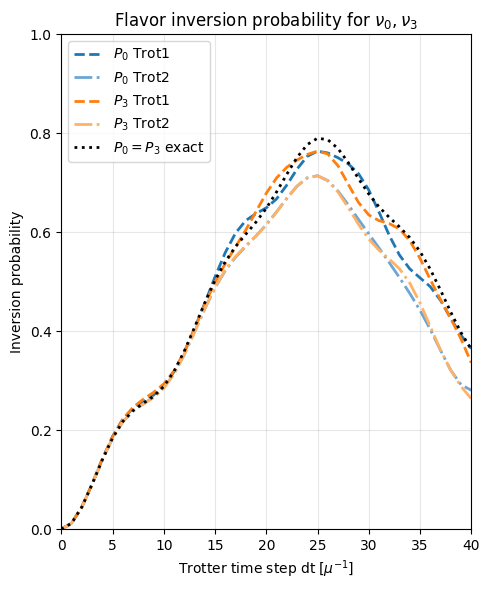

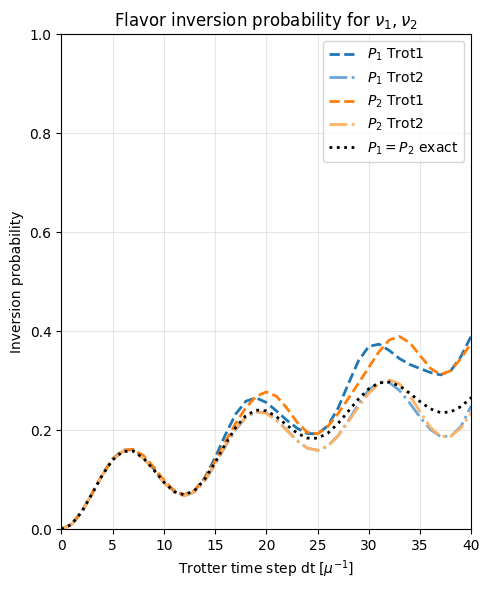

In [18]:
fig, ax = plt.subplots(figsize=(5,6))

c0_t1 = "#1f77b4"
c0_t2 = "#6ba6d6"
c3_t1 = "#ff7f0e"
c3_t2 = "#ffb266"

ax.plot(dt_list, invprob_dt_Trot1_0, linestyle="--", color=c0_t1, linewidth=2, label=r"$P_0$ Trot1")
ax.plot(dt_list, invprob_dt_Trot2_0, linestyle="-.", color=c0_t2, linewidth=2, label=r"$P_0$ Trot2")
ax.plot(dt_list, invprob_dt_Trot1_3, linestyle="--", color=c3_t1, linewidth=2, label=r"$P_3$ Trot1")
ax.plot(dt_list, invprob_dt_Trot2_3, linestyle="-.", color=c3_t2, linewidth=2, label=r"$P_3$ Trot2")
ax.plot(dt_list, invprob_dt_exact_0, linestyle=":", color="#000000", linewidth=2, label=r"$P_0=P_3$ exact")

ax.set_xlabel(r"Trotter time step $\mathrm{dt}\;[\mu^{-1}]$")
ax.set_ylabel(r"Inversion probability")
ax.set_xlim(np.min(dt_list), np.max(dt_list))
ax.set_ylim(0, 1)
ax.set_title(r"Flavor inversion probability for $\nu_0,\nu_3$")
ax.grid(alpha=0.3)
ax.legend()

plt.tight_layout()
fig.savefig(r"C:\Users\edori\Desktop\Nexus\Università\Current\MasterThesis\Images\N4plots\singlestep_flvinv_nu0nu3_N4.pdf", dpi=300)
plt.show()


fig, ax = plt.subplots(figsize=(5,6))

c1_t1 = "#1f77b4"
c1_t2 = "#6ba6d6"
c2_t1 = "#ff7f0e"
c2_t2 = "#ffb266"

ax.plot(dt_list, invprob_dt_Trot1_1, linestyle="--", color=c1_t1, linewidth=2, label=r"$P_1$ Trot1")
ax.plot(dt_list, invprob_dt_Trot2_1, linestyle="-.", color=c1_t2, linewidth=2, label=r"$P_1$ Trot2")
ax.plot(dt_list, invprob_dt_Trot1_2, linestyle="--", color=c2_t1, linewidth=2, label=r"$P_2$ Trot1")
ax.plot(dt_list, invprob_dt_Trot2_2, linestyle="-.", color=c2_t2, linewidth=2, label=r"$P_2$ Trot2")
ax.plot(dt_list, invprob_dt_exact_1, linestyle=":", color="#000000", linewidth=2, label=r"$P_1=P_2$ exact")

ax.set_xlabel(r"Trotter time step $\mathrm{dt}\;[\mu^{-1}]$")
ax.set_ylabel(r"Inversion probability")
ax.set_xlim(np.min(dt_list), np.max(dt_list))
ax.set_ylim(0, 1)
ax.set_title(r"Flavor inversion probability for $\nu_1,\nu_2$")
ax.grid(alpha=0.3)
ax.legend()

plt.tight_layout()
fig.savefig(r"C:\Users\edori\Desktop\Nexus\Università\Current\MasterThesis\Images\N4plots\singlestep_flvinv_nu1nu2_N4.pdf", dpi=300)
plt.show()

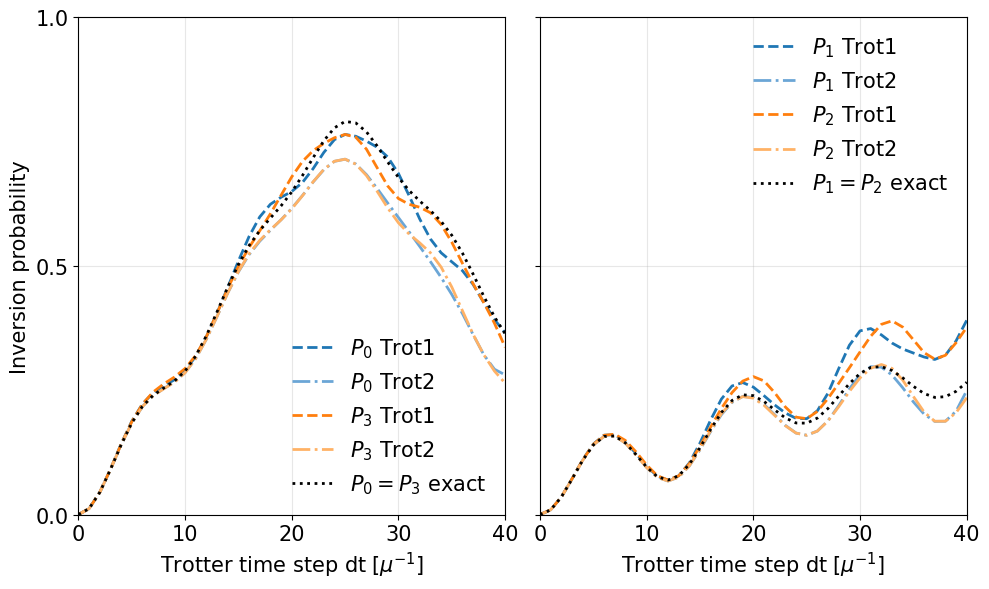

In [23]:
fig, axs = plt.subplots(1, 2, figsize=(10,6), sharex=True, sharey=True)

# --- Top subplot: nu0 & nu3 ---
c0_t1 = "#1f77b4"
c0_t2 = "#6ba6d6"
c3_t1 = "#ff7f0e"
c3_t2 = "#ffb266"

ax = axs[0]
ax.plot(dt_list, invprob_dt_Trot1_0, linestyle="--", color=c0_t1, linewidth=2, label=r"$P_0$ Trot1")
ax.plot(dt_list, invprob_dt_Trot2_0, linestyle="-.", color=c0_t2, linewidth=2, label=r"$P_0$ Trot2")
ax.plot(dt_list, invprob_dt_Trot1_3, linestyle="--", color=c3_t1, linewidth=2, label=r"$P_3$ Trot1")
ax.plot(dt_list, invprob_dt_Trot2_3, linestyle="-.", color=c3_t2, linewidth=2, label=r"$P_3$ Trot2")
ax.plot(dt_list, invprob_dt_exact_0, linestyle=":", color="#000000", linewidth=2, label=r"$P_0=P_3$ exact")

ax.set_xlabel(r"Trotter time step $\mathrm{dt}\;[\mu^{-1}]$", fontsize=15)
ax.set_ylabel(r"Inversion probability", fontsize=15)
ax.set_xlim(np.min(dt_list), np.max(dt_list))
ax.set_ylim(0, 1)
ax.grid(alpha=0.3)
ax.legend(fontsize=15, frameon=False)
ax.set_xticks([0,10,20,30,40])
ax.set_yticks([0,0.5,1])
ax.tick_params("both", labelsize=15)

# --- Bottom subplot: nu1 & nu2 ---
c1_t1 = "#1f77b4"
c1_t2 = "#6ba6d6"
c2_t1 = "#ff7f0e"
c2_t2 = "#ffb266"

ax = axs[1]
ax.plot(dt_list, invprob_dt_Trot1_1, linestyle="--", color=c1_t1, linewidth=2, label=r"$P_1$ Trot1")
ax.plot(dt_list, invprob_dt_Trot2_1, linestyle="-.", color=c1_t2, linewidth=2, label=r"$P_1$ Trot2")
ax.plot(dt_list, invprob_dt_Trot1_2, linestyle="--", color=c2_t1, linewidth=2, label=r"$P_2$ Trot1")
ax.plot(dt_list, invprob_dt_Trot2_2, linestyle="-.", color=c2_t2, linewidth=2, label=r"$P_2$ Trot2")
ax.plot(dt_list, invprob_dt_exact_1, linestyle=":", color="#000000", linewidth=2, label=r"$P_1=P_2$ exact")

ax.set_xlabel(r"Trotter time step $\mathrm{dt}\;[\mu^{-1}]$", fontsize=15)
ax.set_xlim(np.min(dt_list), np.max(dt_list))
ax.set_ylim(0, 1)
ax.grid(alpha=0.3)
ax.legend(fontsize=15, frameon=False)
ax.set_xticks([0,10,20,30,40])
ax.set_yticks([0,0.5,1])
ax.tick_params("both", labelsize=15)

plt.tight_layout()
fig.savefig(r"C:\Users\edori\Desktop\Nexus\Università\Current\MasterThesis\Images\N4plots\singlestep_flvinv_subplots_N4.pdf", dpi=300)
plt.show()